# N02 — Deterministic modes, preparation, and inverse design

This notebook explores the deterministic circuit beyond the calculations shown in the main text.  It computes the eigendirections, constructs slow and fast preparations, predicts energy crossings, and inverts the problem to find preparations with a chosen spectral content.

The central distinction is between the amount of stored energy and the modal content of the initial state.


In [1]:
from pathlib import Path
import json, csv, re, hashlib, warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.linalg import expm

# Locate the project root from the notebook directory or its parents.
def locate_root(start=Path.cwd()):
    candidates = [start, start.parent, start.parent.parent]
    for p in candidates:
        if (p / "experimental_data" / "raw").exists():
            return p.resolve()
    raise FileNotFoundError("Could not locate the project directory containing experimental_data/raw/." )

ROOT = locate_root()
RAW = ROOT / "experimental_data" / "raw"
REF = ROOT / "experimental_data" / "reference"
OUT_DATA = ROOT / "notebook_outputs" / "data"
OUT_FIG = ROOT / "notebook_outputs" / "figures"
OUT_DATA.mkdir(parents=True, exist_ok=True)
OUT_FIG.mkdir(parents=True, exist_ok=True)

# ---------------- Plot-style switch ----------------
# Safe default: executes everywhere with Matplotlib only.
# Local options:
#   PLOT_STYLE = "science-no-latex"  -> requires `pip install scienceplots`
#   PLOT_STYLE = "science-latex"     -> additionally requires a local LaTeX install
PLOT_STYLE = "matplotlib"

def apply_plot_style(style=PLOT_STYLE):
    plt.style.use("default")
    if style.startswith("science"):
        try:
            import scienceplots  # noqa: F401
            plt.style.use(["science", "no-latex"] if style == "science-no-latex" else ["science"])
        except ImportError:
            warnings.warn("scienceplots is not installed; falling back to Matplotlib.")
    mpl.rcParams.update({
        "font.family": "serif",
        "font.serif": ["STIXGeneral", "DejaVu Serif"],
        "mathtext.fontset": "stix",
        "font.size": 9.0,
        "axes.labelsize": 9.0,
        "axes.titlesize": 9.5,
        "legend.fontsize": 7.5,
        "xtick.labelsize": 8.0,
        "ytick.labelsize": 8.0,
        "axes.linewidth": 0.7,
        "lines.linewidth": 1.3,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.04,
    })

apply_plot_style()

# Measured/component values used in the manuscript.
L_H = 44.4e-3
C_F = 454e-6
R_EXT_OHM = 22.2
R_COMP_OHM = 27.9
DETERMINISTIC_RELEASE_S = 7.2e-3

print("Data files located successfully.")
print(f"Plot style: {PLOT_STYLE}")


Data files located successfully.
Plot style: matplotlib


## 1. Drift matrix, eigenvalues, and energy dissipation

For $X=(q,I)^T$,
$$
\dot X=AX,\qquad
A=\begin{pmatrix}0&1\\-1/(LC)&-R/L\end{pmatrix}.
$$
The physical energy is $E=X^T G X/2$ with $G=\operatorname{diag}(1/C,L)$, and the source-free circuit satisfies $\dot E=-RI^2\le0$.


In [2]:
def drift_matrix(L,C,R):
    return np.array([[0.0,1.0],[-1.0/(L*C),-R/L]])

def eig_rates(L,C,R):
    disc = (R/L)**2 - 4/(L*C)
    if disc <= 0:
        raise ValueError("This notebook section assumes an overdamped circuit.")
    root = np.sqrt(disc)
    ls = (-(R/L)+root)/2
    lf = (-(R/L)-root)/2
    return ls,lf

def energy(q,I,L,C):
    return q*q/(2*C) + L*I*I/2

R = R_COMP_OHM
ls, lf = eig_rates(L_H,C_F,R)
rho = abs(lf/ls)
Rc = 2*np.sqrt(L_H/C_F)
print(f"critical R_c = {Rc:.3f} ohm")
print(f"lambda_s = {ls:.3f} s^-1, lambda_f = {lf:.3f} s^-1, rho = {rho:.3f}")
assert R > Rc and lf < ls < 0


critical R_c = 19.779 ohm
lambda_s = -92.591 s^-1, lambda_f = -535.787 s^-1, rho = 5.787


## 2. Modal coefficients are preparation coordinates

With representatives $r_s=(1,\lambda_s)^T$ and $r_f=(1,\lambda_f)^T$,
$$
X(t)=c_s r_s e^{\lambda_s t}+c_f r_f e^{\lambda_f t},
$$
where
$$
c_s=\frac{I_0-\lambda_f q_0}{\lambda_s-\lambda_f},\qquad
c_f=\frac{\lambda_s q_0-I_0}{\lambda_s-\lambda_f}.
$$
A pure fast preparation therefore satisfies $I_0=\lambda_f q_0$; a pure slow preparation satisfies $I_0=\lambda_s q_0$.


In [3]:
def modal_coefficients(q0,I0,ls,lf):
    cs = (I0-lf*q0)/(ls-lf)
    cf = (ls*q0-I0)/(ls-lf)
    return cs,cf

# Choose an energy and place it entirely in the slow or fast mode.
E0 = 1.0e-3

def pure_mode_state(lam,E0,L=L_H,C=C_F):
    q0 = np.sqrt(2*E0/(1/C + L*lam**2))
    return q0, lam*q0

qs,Is = pure_mode_state(ls,E0)
qf,If = pure_mode_state(lf,E0)
print("slow coefficients", modal_coefficients(qs,Is,ls,lf))
print("fast coefficients", modal_coefficients(qf,If,ls,lf))


slow coefficients (np.float64(0.0008798903505465341), np.float64(0.0))
fast coefficients (np.float64(0.0), np.float64(0.000365777215002653))


### Energy-normalized phase space

Define $z_1=q/\sqrt C$ and $z_2=\sqrt L I$. Then $E=(z_1^2+z_2^2)/2$, so equal-energy preparations lie on a circle. The radius is the energy; the angle is the preparation.


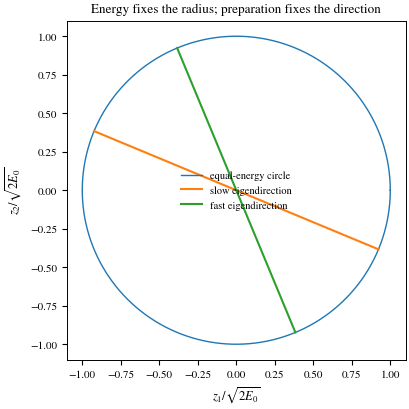

In [4]:
fig, ax = plt.subplots(figsize=(4.8,4.4))
th = np.linspace(0,2*np.pi,500)
ax.plot(np.cos(th),np.sin(th),lw=1.0,label="equal-energy circle")
for lam,label in [(ls,"slow"),(lf,"fast")]:
    v=np.array([1/np.sqrt(C_F),np.sqrt(L_H)*lam]); v/=np.linalg.norm(v)
    ax.plot([-v[0],v[0]],[-v[1],v[1]],lw=1.5,label=f"{label} eigendirection")
ax.set_aspect("equal")
ax.set_xlabel(r"$z_1/\sqrt{2E_0}$")
ax.set_ylabel(r"$z_2/\sqrt{2E_0}$")
ax.legend(frameon=False)
ax.set_title("Energy fixes the radius; preparation fixes the direction")
plt.show()


## 3. Pure-mode crossing criterion

For pure modes,
$$
E_f(t)=E_f(0)e^{2\lambda_f t},\qquad E_s(t)=E_s(0)e^{2\lambda_s t}.
$$
If $E_f(0)>E_s(0)$, the crossing time is
$$
t_\times=\frac{\ln[E_s(0)/E_f(0)]}{2(\lambda_f-\lambda_s)}.
$$
Use the controls below to see that a larger initial energy is compatible with a faster decay when the preparation suppresses the slow mode.


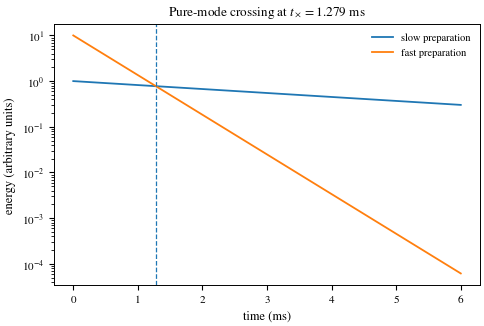

In [5]:
# Reader controls
lambda_s_demo = -100.0
lambda_f_demo = -1000.0
Eslow_uJ = 1.0
Efast_uJ = 10.0

tx = np.log(Eslow_uJ/Efast_uJ)/(2*(lambda_f_demo-lambda_s_demo))
t = np.linspace(0,0.006,500)
Es = Eslow_uJ*np.exp(2*lambda_s_demo*t)
Ef = Efast_uJ*np.exp(2*lambda_f_demo*t)
fig, ax = plt.subplots(figsize=(5.5,3.4))
ax.plot(1e3*t,Es,label="slow preparation")
ax.plot(1e3*t,Ef,label="fast preparation")
ax.axvline(1e3*tx,ls="--",lw=0.9)
ax.set_yscale("log")
ax.set_xlabel("time (ms)")
ax.set_ylabel("energy (arbitrary units)")
ax.legend(frameon=False)
ax.set_title(fr"Pure-mode crossing at $t_\times={1e3*tx:.3f}$ ms")
plt.show()


## 4. Inverse design from the desired mode separation

Using $\rho=|\lambda_f/\lambda_s|$ and the slow **energy** time $\tau_{E,s}=1/(2|\lambda_s|)$,
$$
R=\frac{L(1+\rho)}{2\tau_{E,s}},\qquad
C=\frac{4\tau_{E,s}^2}{L\rho}.
$$
This is useful experimentally because it turns the usual forward problem around: choose the separation and the observable time scale first, then select $R$ and $C$.


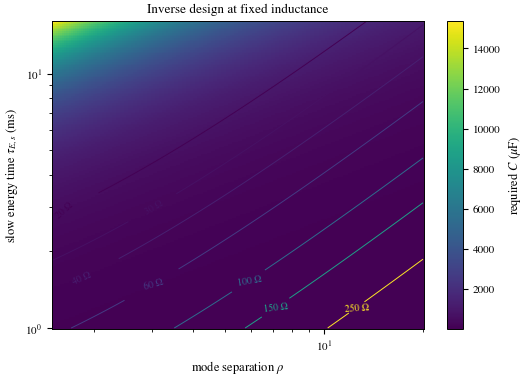

In [6]:
def inverse_design(L,rho,tau_Es):
    R=L*(1+rho)/(2*tau_Es)
    C=4*tau_Es**2/(L*rho)
    return R,C

rho_grid=np.geomspace(1.5,20,180)
tau_grid=np.geomspace(1e-3,16e-3,180)
RRHO,TTAU=np.meshgrid(rho_grid,tau_grid)
Rmap=L_H*(1+RRHO)/(2*TTAU)
Cmap=4*TTAU**2/(L_H*RRHO)

fig, ax=plt.subplots(figsize=(6.0,4.0))
pm=ax.pcolormesh(RRHO,1e3*TTAU,1e6*Cmap,shading="auto")
cs=ax.contour(RRHO,1e3*TTAU,Rmap,levels=[20,30,40,60,100,150,250],linewidths=.7)
ax.clabel(cs,fmt=lambda x:f"{x:g} Ω",fontsize=7)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"mode separation $\rho$")
ax.set_ylabel(r"slow energy time $\tau_{E,s}$ (ms)")
cb=fig.colorbar(pm,ax=ax); cb.set_label(r"required $C$ ($\mu$F)")
ax.set_title("Inverse design at fixed inductance")
plt.show()


## 5. Preparation error and the slow tail

Near a nominal fast preparation, write $I_0=\lambda_f q_0+\delta I$. Then
$$
c_s=\frac{\delta I}{\lambda_s-\lambda_f},
$$
so the late slow-mode **amplitude** is linear in the preparation error while its **energy** is quadratic. This is why small mispreparations can become visible only at late times.


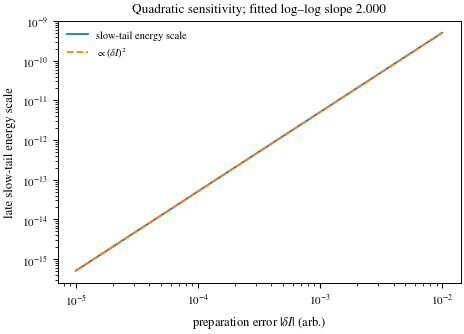

In [7]:
delta=np.geomspace(1e-5,1e-2,80)
slow_amp=np.abs(delta/(ls-lf))
slow_energy=slow_amp**2
coef=np.polyfit(np.log(delta),np.log(slow_energy),1)[0]
fig,ax=plt.subplots(figsize=(5.2,3.4))
ax.loglog(delta,slow_energy,label="slow-tail energy scale")
ax.loglog(delta,slow_energy[0]*(delta/delta[0])**2,ls="--",label=r"$\propto(\delta I)^2$")
ax.set_xlabel(r"preparation error $|\delta I|$ (arb.)")
ax.set_ylabel("late slow-tail energy scale")
ax.legend(frameon=False)
ax.set_title(fr"Quadratic sensitivity; fitted log–log slope {coef:.3f}")
plt.show()
assert abs(coef-2)<1e-10


## What to change when exploring

The most useful controls are `rho`, `tau_Es`, the initial energy ratio, and the preparation angle. Changing them should alter the physics transparently without changing any data-processing or plotting logic.
